In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from src.config import *
from src.io import *
from src.procesamiento import *
from src.visualizacion import *
from src.funciones_complejas import *

# Celda 1: Importaciones y configuración
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import ast
import numpy as np

In [2]:
# CONFIGURACIÓN Y CARGA DE DATOS
############################################################

trayectorias = pd.read_excel(RUTA_EXCEL, sheet_name=2)
df_pacientes = pd.read_excel(RUTA_EXCEL, sheet_name=0) 

# --- NUEVO: AGRUPAR TRAYECTORIAS LARGAS PARA LOS TOPS ---

# Creamos una columna nueva para no romper los gráficos de saltos individuales
trayectorias['ruta_para_top'] = trayectorias['ruta_complejidad_str'].apply(agrupar_trayectorias_largas)


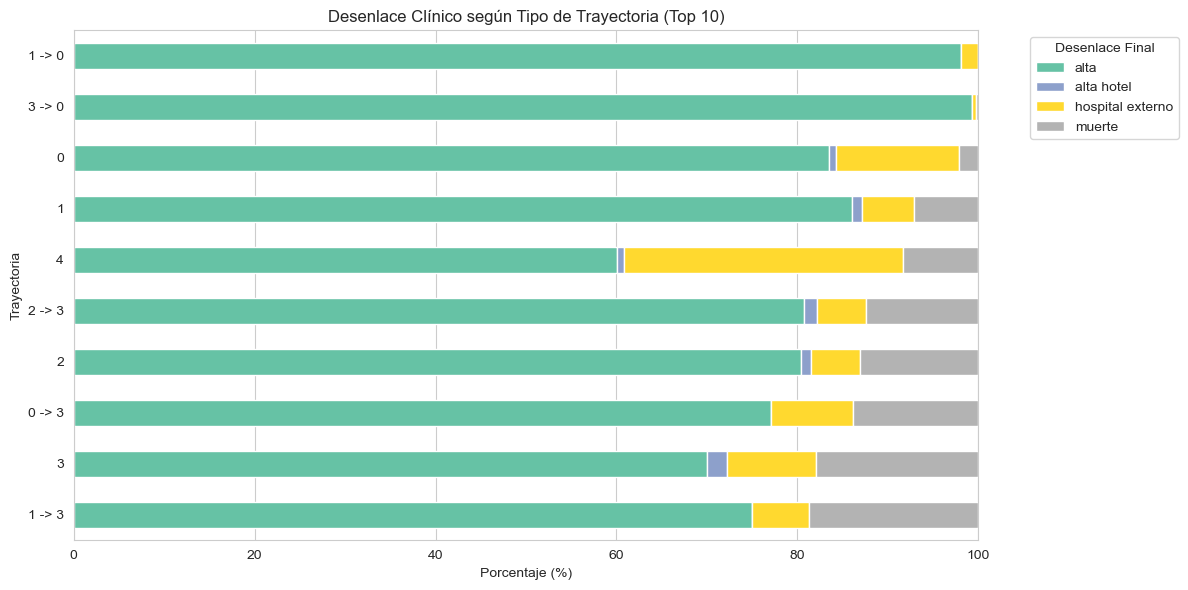

In [3]:
# 1. Desenlaces según el tipo de trayectoria (Alta vs Muerte, etc.)
###################################################################

# Filtramos solo el top 10 o 15 de rutas para que el gráfico sea legible
top_rutas = trayectorias['ruta_para_top'].value_counts().head(10).index
df_top_rutas = trayectorias[trayectorias['ruta_para_top'].isin(top_rutas)]

# Calculamos la proporción de desenlaces por ruta
crosstab_desenlaces = pd.crosstab(
    df_top_rutas['ruta_para_top'], 
    df_top_rutas['motivo_fin_caso'], 
    normalize='index' # Esto lo hace proporcional (del 0 al 1)
) * 100

# Ordenamos por la tasa de mortalidad o alta para darle sentido de lectura
if 'muerte' in crosstab_desenlaces.columns:
    crosstab_desenlaces = crosstab_desenlaces.sort_values('muerte', ascending=False)

# Gráfico
plt.figure(figsize=(12, 6))
crosstab_desenlaces.plot(kind='barh', stacked=True, colormap='Set2', ax=plt.gca())
plt.title('Desenlace Clínico según Tipo de Trayectoria (Top 10)')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Trayectoria')
plt.legend(title='Desenlace Final', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [4]:
# 2. Tiempos por Nodo (Ej: ¿Cuánto en 0 y cuánto en 3?)
# =======================================================

# 1. Cargar episodios (La tabla nueva YA tiene los días y la complejidad calculados)
episodios = pd.read_excel(RUTA_EXCEL, sheet_name='2_Episodios_Cronologicos')

# 2. Identificar pacientes que hicieron una ruta específica (Ej: "0 -> 3")
# (Usamos la variable 'trayectorias' que ya tenías cargada en este notebook)
pacientes_0_3 = trayectorias[trayectorias['ruta_complejidad_str'] == '0 -> 3']['paciente_id']

# 3. Traer SOLO los episodios de esos pacientes específicos
episodios_0_3 = episodios[episodios['paciente_id'].isin(pacientes_0_3)]

# 4. Agrupar y ver las métricas de tiempo en cada nivel
tiempos_por_nodo = episodios_0_3.groupby('nivel_complejidad')['dias_en_nodo'].agg(
    Mediana='median', 
    Promedio='mean', 
    Episodios_Totales='count'
).round(1)

print("Tiempos de internación (en días) para pacientes con ruta '0 -> 3':")
display(tiempos_por_nodo)

# (Se puede encapsular esto en una función rápida si queremos repetirlo para '3 -> 0' o '0 -> 1')

Tiempos de internación (en días) para pacientes con ruta '0 -> 3':


,Mediana,Promedio,Episodios_Totales
nivel_complejidad,,,
0,2.0,2.3,752
3,7.0,9.6,734


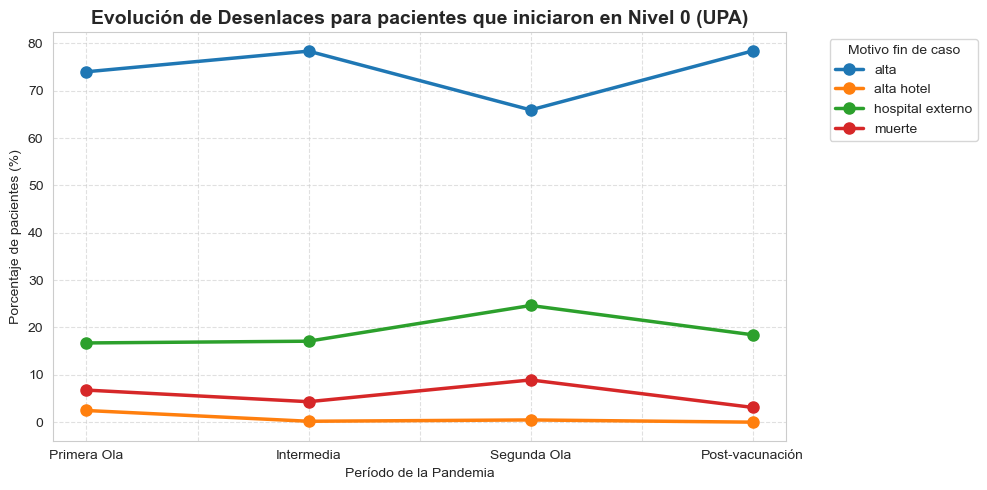

In [5]:
# 3. Agrupación por "Origen de la Trayectoria" en el tiempo
# =========================================================

# 0. BLINDAJE: Si 'Periodo_Covid' no existe (ej: si no corriste la celda anterior), lo creamos acá
if 'Periodo_Covid' not in trayectorias.columns:
    col_fecha = 'fecha_ingreso_red' if 'fecha_ingreso_red' in trayectorias.columns else 'fecha_ingreso_trayectoria'
    trayectorias['Periodo_Covid'] = trayectorias[col_fecha].apply(lambda x: asignar_periodo(x, PERIODOS))

# 1. Creamos una columna para saber dónde empezó (el primer elemento del string)
# Si tu ruta es "0 -> 3", se queda con "0"
trayectorias['nodo_origen'] = trayectorias['ruta_complejidad_str'].apply(
    lambda x: str(x).split('->')[0].strip() if pd.notna(x) else 'Desconocido'
)

# 2. Filtramos solo los que empiezan en UPA (ejemplo: '0')
df_origen_0 = trayectorias[trayectorias['nodo_origen'] == '0']

# 3. Agrupamos por OLA y vemos cómo terminaron
evolucion_upa = pd.crosstab(df_origen_0['Periodo_Covid'], df_origen_0['motivo_fin_caso'], normalize='index') * 100

# 4. Reordenamos cronológicamente según tus periodos
nombres_periodos = [p[0] for p in PERIODOS]
evolucion_upa = evolucion_upa.reindex([p for p in nombres_periodos if p in evolucion_upa.index])

# 5. Graficamos
plt.figure(figsize=(10, 5))
evolucion_upa.plot(kind='line', marker='o', linewidth=2.5, markersize=8, ax=plt.gca())
plt.title('Evolución de Desenlaces para pacientes que iniciaron en Nivel 0 (UPA)', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje de pacientes (%)')
plt.xlabel('Período de la Pandemia')
plt.legend(title='Motivo fin de caso', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

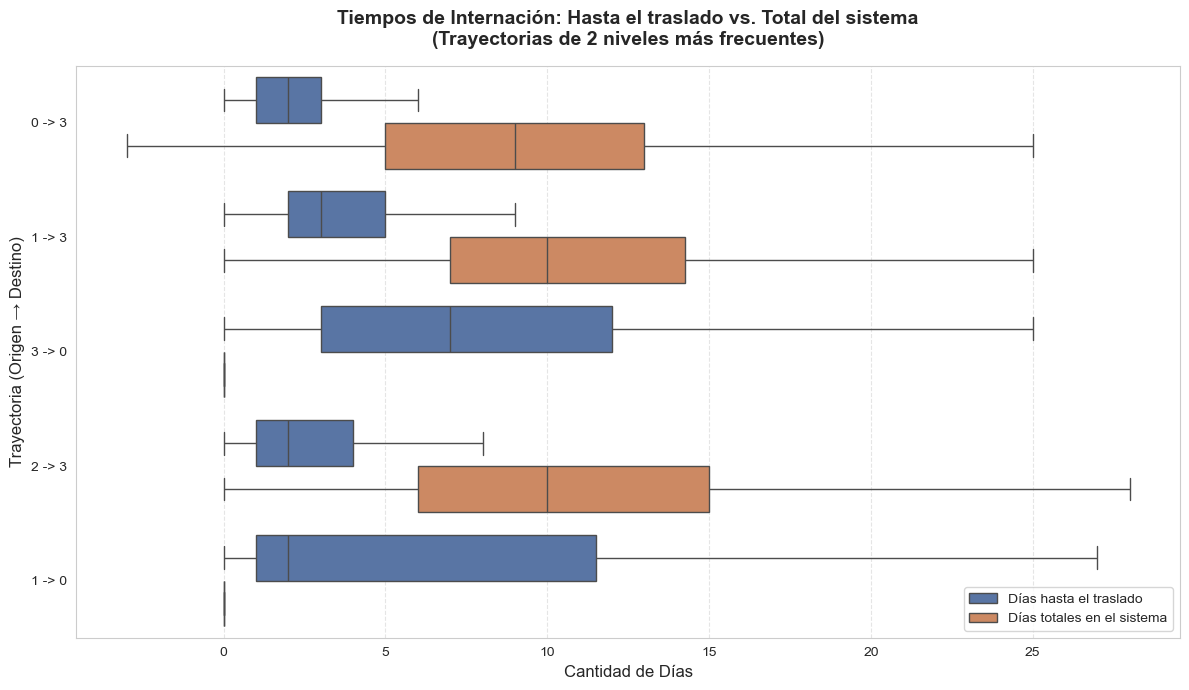

In [6]:
# 4. EL GRÁFICO ESTRELLA: Boxplot Doble (Tiempo al primer traslado vs Tiempo total)
#===================================================================================

# 0. AUTO-CURACIÓN: Traemos los episodios si no están en memoria
if 'episodios' not in locals() and 'episodios' not in globals():
    print("📥 Cargando episodios desde el Excel exportado...")
    episodios = pd.read_excel("../data/revision_dfs.xlsx", sheet_name='2_Episodios_Cronologicos')

# 1. ARMADO DEL CAMPO TIEMPO
# El "tiempo hasta el primer traslado" son exactamente los días de su PRIMER episodio.
# Ordenamos cronológicamente y nos quedamos con la primera parada de cada paciente:
primer_episodio = episodios.sort_values(['paciente_id', 'fecha_ingreso']).groupby('paciente_id').first().reset_index()

# Le pegamos esos días a nuestra tabla de trayectorias (usamos df_grafico para no ensuciar la original)
df_grafico = trayectorias.merge(primer_episodio[['paciente_id', 'dias_en_nodo']], on='paciente_id', how='left')

# Renombramos las columnas para tu código
df_grafico.rename(columns={'dias_en_nodo': 'tiempo_hasta_traslado'}, inplace=True)
df_grafico['tiempo_total_sistema'] = df_grafico['dias_estadia_total']

# 2. Filtrar solo las trayectorias de exactamente 2 pasos (ej: 0->3, 0->1, 3->0)
# Como ahora tu ruta es un texto "0 -> 3", contamos los pedazos separando por la flecha
df_grafico['cantidad_nodos'] = df_grafico['ruta_complejidad_str'].apply(lambda x: len(str(x).split('->')) if pd.notna(x) else 0)
df_2_pasos = df_grafico[df_grafico['cantidad_nodos'] == 2].copy()

# Filtramos las más importantes para no saturar el gráfico
top_rutas_2_pasos = df_2_pasos['ruta_complejidad_str'].value_counts().head(5).index
df_2_pasos_top = df_2_pasos[df_2_pasos['ruta_complejidad_str'].isin(top_rutas_2_pasos)]

# 3. MAGIA DE PANDAS: Usamos 'melt' para poner ambos tiempos en una misma columna
# Esto permite que Seaborn los grafique como dos cajas de distinto color una al lado de la otra
df_melted = pd.melt(
    df_2_pasos_top, 
    id_vars=['ruta_complejidad_str'], 
    value_vars=['tiempo_hasta_traslado', 'tiempo_total_sistema'],
    var_name='Tipo de Métrica', 
    value_name='Días'
)

# Renombramos para que el gráfico quede lindo
df_melted['Tipo de Métrica'] = df_melted['Tipo de Métrica'].replace({
    'tiempo_hasta_traslado': 'Días hasta el traslado',
    'tiempo_total_sistema': 'Días totales en el sistema'
})

# 4. EL BOXPLOT DIRECTO
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_melted, 
    y='ruta_complejidad_str', 
    x='Días', 
    hue='Tipo de Métrica',
    palette=['#4C72B0', '#DD8452'], # Colores piolas y serios
    showfliers=False # Oculta los outliers extremos para que la "caja" se vea bien
)

plt.title('Tiempos de Internación: Hasta el traslado vs. Total del sistema\n(Trayectorias de 2 niveles más frecuentes)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cantidad de Días', fontsize=12)
plt.ylabel('Trayectoria (Origen → Destino)', fontsize=12)
plt.legend(title='', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()